DataSet

In [1]:
!pip install pmdarima

You should consider upgrading via the 'c:\users\amit.ranjan\appdata\local\programs\python\python39\python.exe -m pip install --upgrade pip' command.


In [2]:
!pip install DateTime

You should consider upgrading via the 'c:\users\amit.ranjan\appdata\local\programs\python\python39\python.exe -m pip install --upgrade pip' command.


In [3]:
#Basic Libraries

import pandas as pd
import numpy as np
import datetime as dt
from datetime import datetime
from pandas import Series
import statsmodels.api as sm

In [4]:
!pip install seaborn

You should consider upgrading via the 'c:\users\amit.ranjan\appdata\local\programs\python\python39\python.exe -m pip install --upgrade pip' command.


In [5]:
#Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objs as go
sns.set_style("whitegrid")
%matplotlib inline
import altair as alt
from pylab import rcParams
rcParams['figure.figsize'] = 20, 10


In [6]:
#ignore warnings

import warnings
warnings.filterwarnings('ignore')

In [7]:
!pip freeze


altair==5.3.0
annotated-types==0.7.0
anyio==4.4.0
apikey==0.2.4
asttokens==2.4.1
attrs==23.2.0
beautifulsoup4==4.12.3
blinker==1.8.2
cachetools==5.3.3
certifi==2024.2.2
charset-normalizer==3.3.2
click==8.1.7
colorama==0.4.6
comm==0.2.2
contourpy==1.2.1
cycler==0.12.1
Cython==3.0.10
dateparser==1.2.0
DateTime==5.5
debugpy==1.8.1
decorator==5.1.1
dill==0.3.8
distro==1.9.0
ephem==4.1.5
exceptiongroup==1.2.1
executing==2.0.1
fastjsonschema==2.20.0
fonttools==4.51.0
frozendict==2.4.4
gitdb==4.0.11
GitPython==3.1.43
h11==0.14.0
html5lib==1.1
httpcore==1.0.5
httpx==0.27.0
idna==3.7
imageio==2.34.1
importlib-metadata==7.1.0
importlib-resources==6.4.0
ipykernel==6.29.4
ipython==8.18.1
ipywidgets==8.1.3
jedi==0.19.1
jinja2==3.1.4
joblib==1.4.2
jsonschema==4.22.0
jsonschema-specifications==2023.12.1
jupyter-client==8.6.1
jupyter-core==5.7.2
jupyterlab-widgets==3.0.11
kiwisolver==1.4.5
llvmlite==0.39.1
lxml==5.2.2
markdown-it-py==3.0.0
MarkupSafe==2.1.5
matplotlib==3.9.0
matplotlib-inline==0.1.7
m

In [8]:
#Timeseries model libraries
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima


In [9]:
#Performance metric libraries
from sklearn.metrics import mean_absolute_error, mean_squared_error


Import dataset

In [10]:
reliance_raw = pd.read_csv("D:\Desktop Backup\Python_Practice\Project1\Data\RELIANCE.csv")

In [11]:
reliance_raw.shape

(5097, 15)

In [12]:
reliance_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5097 entries, 0 to 5096
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                5097 non-null   object 
 1   Symbol              5097 non-null   object 
 2   Series              5097 non-null   object 
 3   Prev Close          5097 non-null   float64
 4   Open                5097 non-null   float64
 5   High                5097 non-null   float64
 6   Low                 5097 non-null   float64
 7   Last                5097 non-null   float64
 8   Close               5097 non-null   float64
 9   VWAP                5097 non-null   float64
 10  Volume              5097 non-null   int64  
 11  Turnover            5097 non-null   float64
 12  Trades              2247 non-null   float64
 13  Deliverable Volume  4583 non-null   float64
 14  %Deliverble         4583 non-null   float64
dtypes: float64(11), int64(1), object(3)
memory usage: 597.4

In [13]:
reliance_raw.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,RELIANCE,EQ,233.05,237.50,251.70,237.50,251.70,251.70,249.37,4456424,1.111319e+14,NaN,NaN,NaN
1,2000-01-04,RELIANCE,EQ,251.70,258.40,271.85,251.30,271.85,271.85,263.52,9487878,2.500222e+14,NaN,NaN,NaN
2,2000-01-05,RELIANCE,EQ,271.85,256.65,287.90,256.65,286.75,282.50,274.79,26833684,7.373697e+14,NaN,NaN,NaN
3,2000-01-06,RELIANCE,EQ,282.50,289.00,300.70,289.00,293.50,294.35,295.45,15682286,4.633254e+14,NaN,NaN,NaN
4,2000-01-07,RELIANCE,EQ,294.35,295.00,317.90,293.00,314.50,314.55,308.91,19870977,6.138388e+14,NaN,NaN,NaN


Dataset Details

# Date - Date of trade
# symbol - Name of the company (Reliance)
# Series - We have only one series(EQ): It stands for Equity.
# Prev Close - Refers to the prior day's final price.
# Open - The open is the starting period of trading.
# High - Highest price.
# Low - Lowest price.
# Last - The last price is simply the most recent one
# Close - The close.
# VWAP(Volume-weighted average price)- It is the ratio of the value traded to total volume traded over a
# particular time horizon. It is a measure of the average price at which a stock is traded over the trading
# horizon

# Volume - It is the amount of a security that was traded during a given period of time
# Turnover -It is a measure of sellers versus buyers of a particular stock. It is calculated by dividing the
# daily volume of a stock by the "float" of a stock, which is the number of shares available for sale by the
# general trading public.
# Trades- The number of shares being traded on a given day is called trading volumes
# Deliverabe Volume - quantity of shares which actually move from one set of people (who had those
# shares in their demat account before today and are selling today) to another set of people (who have
# purchased those shares
# %Deliverable - shares which are actually transferred from one person's to another's demat account.

In [14]:
reliance_raw.describe()

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
count,5097.000000,5097.000000,5097.000000,5097.000000,5097.000000,5097.000000,5097.000000,5.097000e+03,5.097000e+03,2.247000e+03,4.583000e+03,4583.000000
mean,968.800824,970.235894,984.038817,955.105081,968.906092,969.089435,969.631030,5.186155e+06,5.047001e+14,1.243892e+05,2.179294e+06,0.440426
std,541.854956,543.235347,552.724884,531.387342,541.689022,541.854759,541.885341,4.267713e+06,5.510347e+14,9.884481e+04,1.796170e+06,0.144242
min,203.200000,205.500000,219.500000,197.150000,203.300000,203.200000,212.290000,5.282000e+04,4.295543e+12,2.991000e+03,2.909700e+04,0.076300
25%,552.750000,555.000000,564.300000,545.600000,552.650000,552.950000,552.640000,2.784741e+06,2.145437e+14,7.000400e+04,1.164656e+06,0.329200
50%,921.000000,922.100000,932.500000,911.300000,920.450000,921.000000,922.390000,4.096597e+06,3.529453e+14,9.606200e+04,1.751404e+06,0.456400
75%,1151.400000,1151.250000,1174.700000,1128.000000,1152.000000,1152.300000,1148.050000,6.245328e+06,6.133209e+14,1.439110e+05,2.604270e+06,0.548000
max,3220.850000,3298.000000,3298.000000,3141.300000,3223.000000,3220.850000,3197.750000,6.523089e+07,8.835030e+15,1.194059e+06,3.495888e+07,0.978300


Insights: There are many outliers in our dataset as we can see the max is 3 times the 75th percentile
The standard deviation and other statistical measurements is more or less equal among all the features

Data preparation

In [15]:
#Creating a copy
reliance_analysis=reliance_raw.copy()

In [16]:
#Coverting date column to datetime data type

reliance_analysis['Date'] = reliance_analysis['Date'].apply(pd.to_datetime)

In [17]:
#Extracting Month, Week, Day,Day of week
reliance_analysis['Month'] = reliance_analysis['Date'].dt.month
# reliance_analysis['WeekDay'] = reliance_analysis['Date'].dt.weekday
reliance_analysis['Day'] = reliance_analysis['Date'].dt.day
reliance_analysis['Day of week'] = reliance_analysis['Date'].dt.dayofweek
reliance_analysis['Year'] = reliance_analysis['Date'].dt.year

In [18]:
# reliance_analysis.drop('WeekDay', axis=1, inplace=True)
# reliance_analysis.drop("Week", axis=1, inplace=True)

In [19]:
reliance_analysis[['Date', 'Month', 'Day', 'Day of week','Year']].head(35)

,Date,Month,Day,Day of week,Year
0,2000-01-03,1,3,0,2000
1,2000-01-04,1,4,1,2000
2,2000-01-05,1,5,2,2000
3,2000-01-06,1,6,3,2000
4,2000-01-07,1,7,4,2000
5,2000-01-10,1,10,0,2000
6,2000-01-11,1,11,1,2000
7,2000-01-12,1,12,2,2000
8,2000-01-13,1,13,3,2000
9,2000-01-14,1,14,4,2000


In [20]:
reliance_analysis.set_index("Date", drop=False, inplace=True) #drop false will keep the column in dataframe which was indexed

In [21]:
reliance_analysis.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble,Month,Day,Day of week,Year
Date,,,,,,,,,,,,,,,,,,,
2000-01-03,2000-01-03,RELIANCE,EQ,233.05,237.50,251.70,237.50,251.70,251.70,249.37,4456424,1.111319e+14,NaN,NaN,NaN,1,3,0,2000
2000-01-04,2000-01-04,RELIANCE,EQ,251.70,258.40,271.85,251.30,271.85,271.85,263.52,9487878,2.500222e+14,NaN,NaN,NaN,1,4,1,2000
2000-01-05,2000-01-05,RELIANCE,EQ,271.85,256.65,287.90,256.65,286.75,282.50,274.79,26833684,7.373697e+14,NaN,NaN,NaN,1,5,2,2000
2000-01-06,2000-01-06,RELIANCE,EQ,282.50,289.00,300.70,289.00,293.50,294.35,295.45,15682286,4.633254e+14,NaN,NaN,NaN,1,6,3,2000
2000-01-07,2000-01-07,RELIANCE,EQ,294.35,295.00,317.90,293.00,314.50,314.55,308.91,19870977,6.138388e+14,NaN,NaN,NaN,1,7,4,2000


In [22]:
reliance_analysis.iloc[:,15:].head()

,Month,Day,Day of week,Year
Date,,,,
2000-01-03,1,3,0,2000
2000-01-04,1,4,1,2000
2000-01-05,1,5,2,2000
2000-01-06,1,6,3,2000
2000-01-07,1,7,4,2000


In [23]:
reliance_analysis.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5097 entries, 2000-01-03 to 2020-06-30
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                5097 non-null   datetime64[ns]
 1   Symbol              5097 non-null   object        
 2   Series              5097 non-null   object        
 3   Prev Close          5097 non-null   float64       
 4   Open                5097 non-null   float64       
 5   High                5097 non-null   float64       
 6   Low                 5097 non-null   float64       
 7   Last                5097 non-null   float64       
 8   Close               5097 non-null   float64       
 9   VWAP                5097 non-null   float64       
 10  Volume              5097 non-null   int64         
 11  Turnover            5097 non-null   float64       
 12  Trades              2247 non-null   float64       
 13  Deliverable Volume  4583 non-n

In [24]:
#Imputing null values with mean

reliance_analysis.isnull().sum()

Date                     0
Symbol                   0
Series                   0
Prev Close               0
Open                     0
High                     0
Low                      0
Last                     0
Close                    0
VWAP                     0
Volume                   0
Turnover                 0
Trades                2850
Deliverable Volume     514
%Deliverble            514
Month                    0
Day                      0
Day of week              0
Year                     0
dtype: int64

In [25]:
# Trade fill blank with mean
reliance_analysis.fillna(reliance_analysis['Trades'].mean(), inplace=True)

In [26]:
# Delivery volume and %Delivery fill na with mean
reliance_analysis.fillna(reliance_analysis['Deliverable Volume'].mean(), inplace=True)
reliance_analysis.fillna(reliance_analysis['%Deliverble'].mean(), inplace=True)

In [27]:
reliance_analysis.isnull().sum()

Date                  0
Symbol                0
Series                0
Prev Close            0
Open                  0
High                  0
Low                   0
Last                  0
Close                 0
VWAP                  0
Volume                0
Turnover              0
Trades                0
Deliverable Volume    0
%Deliverble           0
Month                 0
Day                   0
Day of week           0
Year                  0
dtype: int64

Data Visualization
Exploratory data analysis is a core part of time series analysis. In this phase, we will witness a lot of line
graphs which can help us understand the trend, seasonality and many other concepts from time series
analysis

Distribution of stock measures
Let's witness the histogram distribution of the stock measures such as open,close,high,low and as well as
VWAP

In [31]:
#Size and style of the plot

plt.figure(figsize = (15,7))


<Figure size 1500x700 with 0 Axes>

<Figure size 1500x700 with 0 Axes>

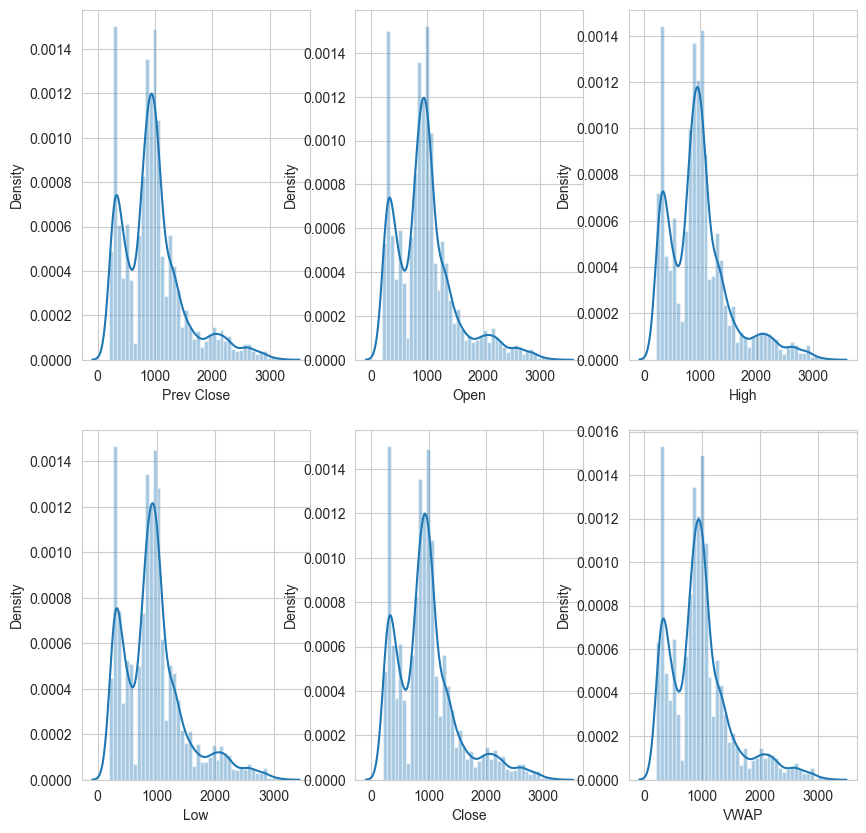

In [32]:
#Subplots of distplot

plt.subplot(231)
sns.distplot(reliance_analysis['Prev Close'])
fig = plt.gcf()
fig.set_size_inches(10,10)

plt.subplot(232)
sns.distplot(reliance_analysis['Open'])
fig = plt.gcf()
fig.set_size_inches(10,10)

plt.subplot(233)
sns.distplot(reliance_analysis['High'])
fig = plt.gcf()
fig.set_size_inches(10,10)

plt.subplot(234)
sns.distplot(reliance_analysis['Low'])
fig = plt.gcf()
fig.set_size_inches(10,10)

plt.subplot(235)
sns.distplot(reliance_analysis['Close'])
fig = plt.gcf()
fig.set_size_inches(10,10)

plt.subplot(236)
sns.distplot(reliance_analysis['VWAP'])
fig = plt.gcf()
fig.set_size_inches(10,10)



All measure exihibit equal distribution
all measures are rightly skewed

Univariate Analysis
VWAP over time
Now let's see the Volume-weighted average price over the time. Please feel free to use the range slider to
analyzeover time

In [33]:
fig = px.line(reliance_analysis, x='Date', y='VWAP',title='VWAP over Years(Use Rangeslid)')
fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=list([
            dict(count=1, label="1m", step="month", stepmode="backward"),
            dict(count=6, label="6m", step="month", stepmode="backward"),
            dict(count=1, label="YTD", step="year", stepmode="todate"),
            dict(count=1, label="1y", step="year", stepmode="backward"),
            dict(step="all")
        ])
    )
)
# fig.show()

Insights:
There has been a gradual increase in the trend of VWAP over years
There were two spikes in Jan 2008 and May-Oct 2009

Univariate analysis of Open,Close,High and Low

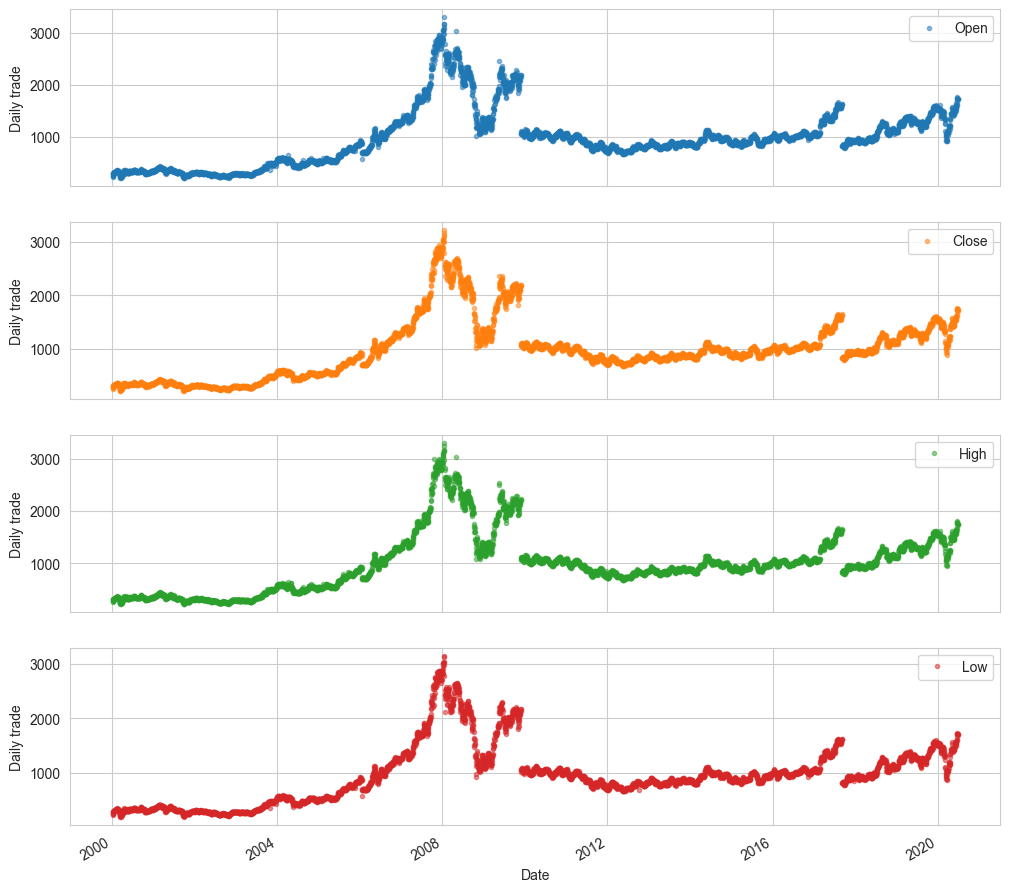

In [34]:
cols_plot = ['Open', 'Close', 'High','Low']

axes = reliance_analysis[cols_plot].plot(marker='.', alpha=0.5, linestyle='None', figsize=(12,12), subplots=True)

for ax in axes:
    ax.set_ylabel('Daily trade')

Insights: Theres a break between 2008-2012 and 2016-2020. It signifies a sudden dip in the market for
Reliance.

Univariate analysis of Volume of share over the years

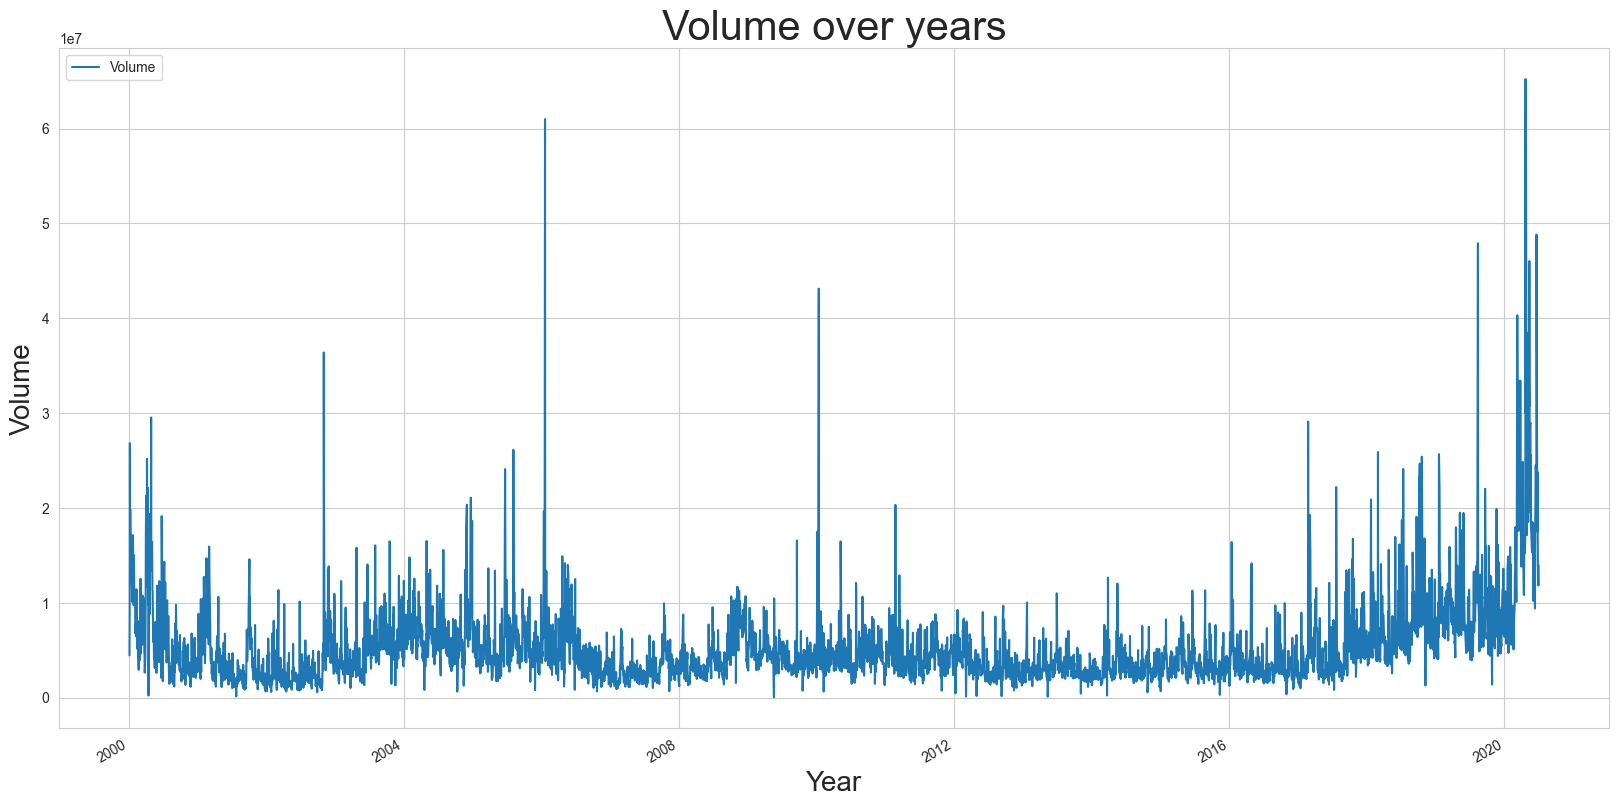

In [35]:
ax=reliance_analysis[['Volume']].plot(stacked=True)
ax.set_title('Volume over years',fontsize= 30)
ax.set_xlabel('Year',fontsize = 20)
ax.set_ylabel('Volume',fontsize = 20)
plt.show()

Insights:
There have been huge number of shared in 2020. This could be due to the reign of Jio and Investment
by top tech gaints like Facebook and Google.
The thin phase lie between 2008-2016, in this phase there hasn't been big volumes traded during these
years.
Reliance have a strong foot in India and has got the trust of the citizens of India that is a valuable
company.

Bivariate analysis
Open Vs Close over time

In [36]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=reliance_analysis['Date'], y=reliance_analysis['Open'],name='Open',line=dict(color='blue'),opacity=0.8))
fig.add_trace(go.Scatter(x=reliance_analysis['Date'],y=reliance_analysis['Close'],name='Close',line=dict(color='red'),opacity=0.8))

fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=list([
            dict(count=1, label="1m", step="month", stepmode="backward"),
            dict(count=6, label="6m", step="month", stepmode="backward"),
            dict(count=1, label="YTD", step="year", stepmode="todate"),
            dict(count=1, label="1y", step="year", stepmode="backward"),
            dict(step="all")
        ])
    )
)

fig.update_layout(title_text='Open Vs Close', yaxis_title = "Value")

There's one place where you can notice a big difference is on May 2,2008 where the opening starts
with 3026 and closes at 2674.5

High vs Low (Now, lets look at the high and low parameters over the years)

In [37]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=reliance_analysis['Date'],y=reliance_analysis['High'],name='High',opacity=0.8))
fig.add_trace(go.Scatter(x=reliance_analysis['Date'],y=reliance_analysis['Low'],name='Low', opacity=0.8))

fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=list([
            dict(count=1, label="1m", step="month", stepmode="backward"),
            dict(count=6, label="6m", step="month", stepmode="backward"),
            dict(count=1, label="YTD", step="year", stepmode="todate"),
            dict(count=1, label="1y", step="year", stepmode="backward"),
            dict(step="all")
        ])
    )
)

fig.update_layout(title_text='High Vs Low',plot_bgcolor='rgb(248, 248, 255)')

Moving average analysis
Moving average is a smoothing technique applied to time series to remove the fine-grained variation between time steps.
The hope of smoothing is to remove noise and better expose the signal
Moving averages are a simple and common type of smoothing used in time series analysis and time series forecasting. 
Calculating a moving average involves creating a new series where the values are comprised of the average of raw observations in the original time series. moving average requires that you specify a window size called the window width.
This defines the number of raw observations used to calculate the moving average value.
The “moving” part in the moving average refers to the fact that the window defined by the window width is slid along the time series to calculate the average values in the new series.

In [38]:
# Making a copy
reliance_lag=reliance_analysis.copy()
reliance_lag

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble,Month,Day,Day of week,Year
Date,,,,,,,,,,,,,,,,,,,
2000-01-03,2000-01-03,RELIANCE,EQ,233.05,237.50,251.70,237.50,251.70,251.70,249.37,4456424,1.111319e+14,124389.192256,1.243892e+05,124389.192256,1,3,0,2000
2000-01-04,2000-01-04,RELIANCE,EQ,251.70,258.40,271.85,251.30,271.85,271.85,263.52,9487878,2.500222e+14,124389.192256,1.243892e+05,124389.192256,1,4,1,2000
2000-01-05,2000-01-05,RELIANCE,EQ,271.85,256.65,287.90,256.65,286.75,282.50,274.79,26833684,7.373697e+14,124389.192256,1.243892e+05,124389.192256,1,5,2,2000
2000-01-06,2000-01-06,RELIANCE,EQ,282.50,289.00,300.70,289.00,293.50,294.35,295.45,15682286,4.633254e+14,124389.192256,1.243892e+05,124389.192256,1,6,3,2000
2000-01-07,2000-01-07,RELIANCE,EQ,294.35,295.00,317.90,293.00,314.50,314.55,308.91,19870977,6.138388e+14,124389.192256,1.243892e+05,124389.192256,1,7,4,2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-06-24,2020-06-24,RELIANCE,EQ,1720.90,1735.90,1772.70,1711.70,1732.50,1727.85,1739.65,23808524,4.141852e+15,488048.000000,5.829283e+06,0.244800,6,24,2,2020
2020-06-25,2020-06-25,RELIANCE,EQ,1727.85,1727.00,1749.00,1713.05,1719.00,1717.90,1728.41,18312705,3.165180e+15,318478.000000,6.775567e+06,0.370000,6,25,3,2020
2020-06-26,2020-06-26,RELIANCE,EQ,1717.90,1728.80,1752.00,1717.00,1750.00,1741.65,1731.91,14270695,2.471551e+15,279769.000000,5.042368e+06,0.353300,6,26,4,2020


In [39]:
#Reset index
reliance_lag.reset_index(drop=True, inplace=True)
reliance_lag

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble,Month,Day,Day of week,Year
0,2000-01-03,RELIANCE,EQ,233.05,237.50,251.70,237.50,251.70,251.70,249.37,4456424,1.111319e+14,124389.192256,1.243892e+05,124389.192256,1,3,0,2000
1,2000-01-04,RELIANCE,EQ,251.70,258.40,271.85,251.30,271.85,271.85,263.52,9487878,2.500222e+14,124389.192256,1.243892e+05,124389.192256,1,4,1,2000
2,2000-01-05,RELIANCE,EQ,271.85,256.65,287.90,256.65,286.75,282.50,274.79,26833684,7.373697e+14,124389.192256,1.243892e+05,124389.192256,1,5,2,2000
3,2000-01-06,RELIANCE,EQ,282.50,289.00,300.70,289.00,293.50,294.35,295.45,15682286,4.633254e+14,124389.192256,1.243892e+05,124389.192256,1,6,3,2000
4,2000-01-07,RELIANCE,EQ,294.35,295.00,317.90,293.00,314.50,314.55,308.91,19870977,6.138388e+14,124389.192256,1.243892e+05,124389.192256,1,7,4,2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5092,2020-06-24,RELIANCE,EQ,1720.90,1735.90,1772.70,1711.70,1732.50,1727.85,1739.65,23808524,4.141852e+15,488048.000000,5.829283e+06,0.244800,6,24,2,2020
5093,2020-06-25,RELIANCE,EQ,1727.85,1727.00,1749.00,1713.05,1719.00,1717.90,1728.41,18312705,3.165180e+15,318478.000000,6.775567e+06,0.370000,6,25,3,2020
5094,2020-06-26,RELIANCE,EQ,1717.90,1728.80,1752.00,1717.00,1750.00,1741.65,1731.91,14270695,2.471551e+15,279769.000000,5.042368e+06,0.353300,6,26,4,2020
5095,2020-06-29,RELIANCE,EQ,1741.65,1728.05,1739.75,1715.55,1722.70,1723.15,1724.38,11825126,2.039106e+15,225499.000000,4.609009e+06,0.389800,6,29,0,2020


In [40]:
#Creating lag features
lag_features = ["High", "Low", "Volume", "VWAP"]

In [41]:
# Taking the number of days in window
window1 = 3
window2 = 7
window3 = 30

In [42]:
#Rolling mean

df_rolled_3d = reliance_lag[lag_features].rolling(window=window1, min_periods=0)
df_rolled_7d = reliance_lag[lag_features].rolling(window=window2, min_periods=0)
df_rolled_30d = reliance_lag[lag_features].rolling(window=window3, min_periods=0)

In [43]:
df_rolled_3d

Rolling [window=3,min_periods=0,center=False,axis=0,method=single]

In [44]:
#Moving average
df_mean_3d = df_rolled_3d.mean().shift(1).reset_index().astype(np.float32)
df_mean_7d = df_rolled_7d.mean().shift(1).reset_index().astype(np.float32)
df_mean_30d = df_rolled_30d.mean().shift(1).reset_index().astype(np.float32)

In [46]:
#Standard deviation
df_std_3d = df_rolled_3d.std().shift(1).reset_index().astype(np.float32)
df_std_7d = df_rolled_7d.std().shift(1).reset_index().astype(np.float32)
df_std_30d = df_rolled_30d.std().shift(1).reset_index().astype(np.float32)

In [48]:
# Adding the features to the dataframe
for feature in lag_features:
    reliance_lag[f"{feature}_mean_lag{window1}"] = df_mean_3d[feature]
    reliance_lag[f"{feature}_mean_lag{window2}"] = df_mean_7d[feature]
    reliance_lag[f"{feature}_mean_lag{window3}"] = df_mean_30d[feature]
    reliance_lag[f"{feature}_std_lag{window1}"] = df_std_3d[feature]
    reliance_lag[f"{feature}_std_lag{window2}"] = df_std_7d[feature]
    reliance_lag[f"{feature}_std_lag{window3}"] = df_std_30d[feature]


In [49]:
reliance_lag.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,...,Volume_mean_lag30,Volume_std_lag3,Volume_std_lag7,Volume_std_lag30,VWAP_mean_lag3,VWAP_mean_lag7,VWAP_mean_lag30,VWAP_std_lag3,VWAP_std_lag7,VWAP_std_lag30
0,2000-01-03,RELIANCE,EQ,233.05,237.50,251.70,237.50,251.70,251.70,249.37,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2000-01-04,RELIANCE,EQ,251.70,258.40,271.85,251.30,271.85,271.85,263.52,...,4456424.0,NaN,NaN,NaN,249.369995,249.369995,249.369995,NaN,NaN,NaN
2,2000-01-05,RELIANCE,EQ,271.85,256.65,287.90,256.65,286.75,282.50,274.79,...,6972151.0,3557775.25,3557775.25,3557775.25,256.445007,256.445007,256.445007,10.005561,10.005561,10.005561
3,2000-01-06,RELIANCE,EQ,282.50,289.00,300.70,289.00,293.50,294.35,295.45,...,13592662.0,11739778.00,11739778.00,11739778.00,262.559998,262.559998,262.559998,12.737163,12.737163,12.737163
4,2000-01-07,RELIANCE,EQ,294.35,295.00,317.90,293.00,314.50,314.55,308.91,...,14115068.0,8790159.00,9642262.00,9642262.00,277.920013,270.782501,270.782501,16.193483,19.457516,19.457516


In [50]:
reliance_lag.set_index("Date", drop=False, inplace=True)
reliance_lag.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,...,Volume_mean_lag30,Volume_std_lag3,Volume_std_lag7,Volume_std_lag30,VWAP_mean_lag3,VWAP_mean_lag7,VWAP_mean_lag30,VWAP_std_lag3,VWAP_std_lag7,VWAP_std_lag30
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,2000-01-03,RELIANCE,EQ,233.05,237.50,251.70,237.50,251.70,251.70,249.37,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-04,2000-01-04,RELIANCE,EQ,251.70,258.40,271.85,251.30,271.85,271.85,263.52,...,4456424.0,NaN,NaN,NaN,249.369995,249.369995,249.369995,NaN,NaN,NaN
2000-01-05,2000-01-05,RELIANCE,EQ,271.85,256.65,287.90,256.65,286.75,282.50,274.79,...,6972151.0,3557775.25,3557775.25,3557775.25,256.445007,256.445007,256.445007,10.005561,10.005561,10.005561
2000-01-06,2000-01-06,RELIANCE,EQ,282.50,289.00,300.70,289.00,293.50,294.35,295.45,...,13592662.0,11739778.00,11739778.00,11739778.00,262.559998,262.559998,262.559998,12.737163,12.737163,12.737163
2000-01-07,2000-01-07,RELIANCE,EQ,294.35,295.00,317.90,293.00,314.50,314.55,308.91,...,14115068.0,8790159.00,9642262.00,9642262.00,277.920013,270.782501,270.782501,16.193483,19.457516,19.457516


High vs Low with mean and standard deviation lag - 30 days

In [51]:
#Printing the high curve
fig = go.Figure()
fig.add_trace(go.Scatter(x=reliance_lag['Date'],y=reliance_lag['High_mean_lag30'],name='High_mean_lag30',line=dict(color='green'),opacity=0.8))
fig.add_trace(go.Scatter(x=reliance_lag['Date'],y=reliance_lag['High_std_lag30'],name='High_std_lag30',line=dict(color='green'),opacity=0.8))

#Printing the low curve
fig.add_trace(go.Scatter(x=reliance_lag['Date'],y=reliance_lag['Low_mean_lag30'],name='Low_mean_lag30',line=dict(color='orange'),opacity=0.8))
fig.add_trace(go.Scatter(x=reliance_lag['Date'],y=reliance_lag['Low_std_lag30'],name='Low_std_lag30',line=dict(color='orange'),opacity=0.8))


fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=list([
            dict(count=1, label="1m", step="month", stepmode="backward"),
            dict(count=6, label="6m", step="month", stepmode="backward"),
            dict(count=1, label="YTD", step="year", stepmode="todate"),
            dict(count=1, label="1y", step="year", stepmode="backward"),
            dict(step="all")
        ])
    )
)

Insight : Considering the standard deviation,there's a high deviation whenever there is a drop in the price of
stock.
With the help of standard deviation we can understand where the company faced loss.
Even though the lag curve isn't much less with noise, we have a clear idea on how the high and low
price move over time

In [52]:
#Printing the Volume curve
fig = go.Figure()
fig.add_trace(go.Scatter(x=reliance_lag['Date'],y=reliance_lag['Volume'],name='Volume',line=dict(color='green'),opacity=0.8))
fig.add_trace(go.Scatter(x=reliance_lag['Date'],y=reliance_lag['Volume_mean_lag30'],name='Volume_mean_lag30',line=dict(color='yellow'),opacity=0.8))
fig.add_trace(go.Scatter(x=reliance_lag['Date'],y=reliance_lag['Volume_std_lag30'],name='Volume_std_lag30',line=dict(color='blue'),opacity=0.8))



fig.update_xaxes(
    rangeslider_visible = True,
    rangeselector = dict (
        buttons = list([
            dict(count=1, label="YTD", step="year", stepmode="todate"),
            dict(step = "all")]
        )
    )
)

Insights:
Here we have a neat representation of the moving average and standard deviation graph
There's a lot of deviation when the volume value is reaching 2020 and corresponding mean is high
compared to standard deviation

Wrath of Covid 19

In [71]:
#Setting the range of base plot
fig = px.line(reliance_analysis, x='Date', y='Volume',title="Volume during Phase 1 Lockdown")

In [73]:
# Adding the shape in the dates
fig.update_layout(
    shapes=
    [dict( type="rect", xref="x", yref="paper",x0="2020-03-23",y0=0,x1="2021-04-14",y1=1,fillcolor="LightSalmon",opacity=0.5,
    layer="below",line_width=0),
# Second phase Lockdown
    dict(type="rect",xref="x",yref="paper",x0="2021-04-15",y0=0,x1="2022-05-03",y1=1,fillcolor="Green",opacity=0.5,
    layer="below",line_width=0,)],

    annotations = [dict(x='2020-04-15', y=0.99, xref='x', yref='paper',showarrow=False, xanchor='right', text='Phase 1 Lockdown'),
                    dict(x='2020-05-12', y=0.99, xref='x', yref='paper',showarrow=False, xanchor='right', text='Phase 2 Lockdown')])

fig.show()